In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from pyBigKinds.preprocessing import keyword_dataframe

import math
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams['axes.unicode_minus'] = False

pd.options.display.float_format = '{:.0f}'.format

In [2]:
import os
os.chdir("../../model/schizophrenia")

topic_df = pd.read_excel("topic_name_schizo.xlsx", engine="openpyxl")
topic_df = topic_df[["Group", "Topic"]]

all_df = pd.read_excel("df_schizo.xlsx", engine="openpyxl")
all_df.columns = ["name", "press", "date", "keywords", "year"]

doc_df = pd.read_excel("doc_topics_schizo.xlsx", engine="openpyxl")

analysis_df = pd.merge(doc_df, all_df[["name", "press", "year"]], how = "left")
analysis_df = analysis_df.drop_duplicates(["name", "Document", "press"])

df = pd.merge(analysis_df, topic_df, on='Topic')
df["year_range"] = df["year"].apply(lambda x: math.floor(x/10)*10)

In [3]:
conditions = [
    (df["press"].str.contains("조선일보")),
    (df["press"].str.contains("동아일보")),
    (df["press"].str.contains("한겨레")),
    (df["press"].str.contains("경향신문")),
    (df["press"].str.contains("한국일보")),
    (df["press"].str.contains("서울신문")),
]
choices = ["보수", "보수", "진보", "진보", "중도", "중도"]

df["Partizanship"] = np.select(conditions, choices, default='Other')

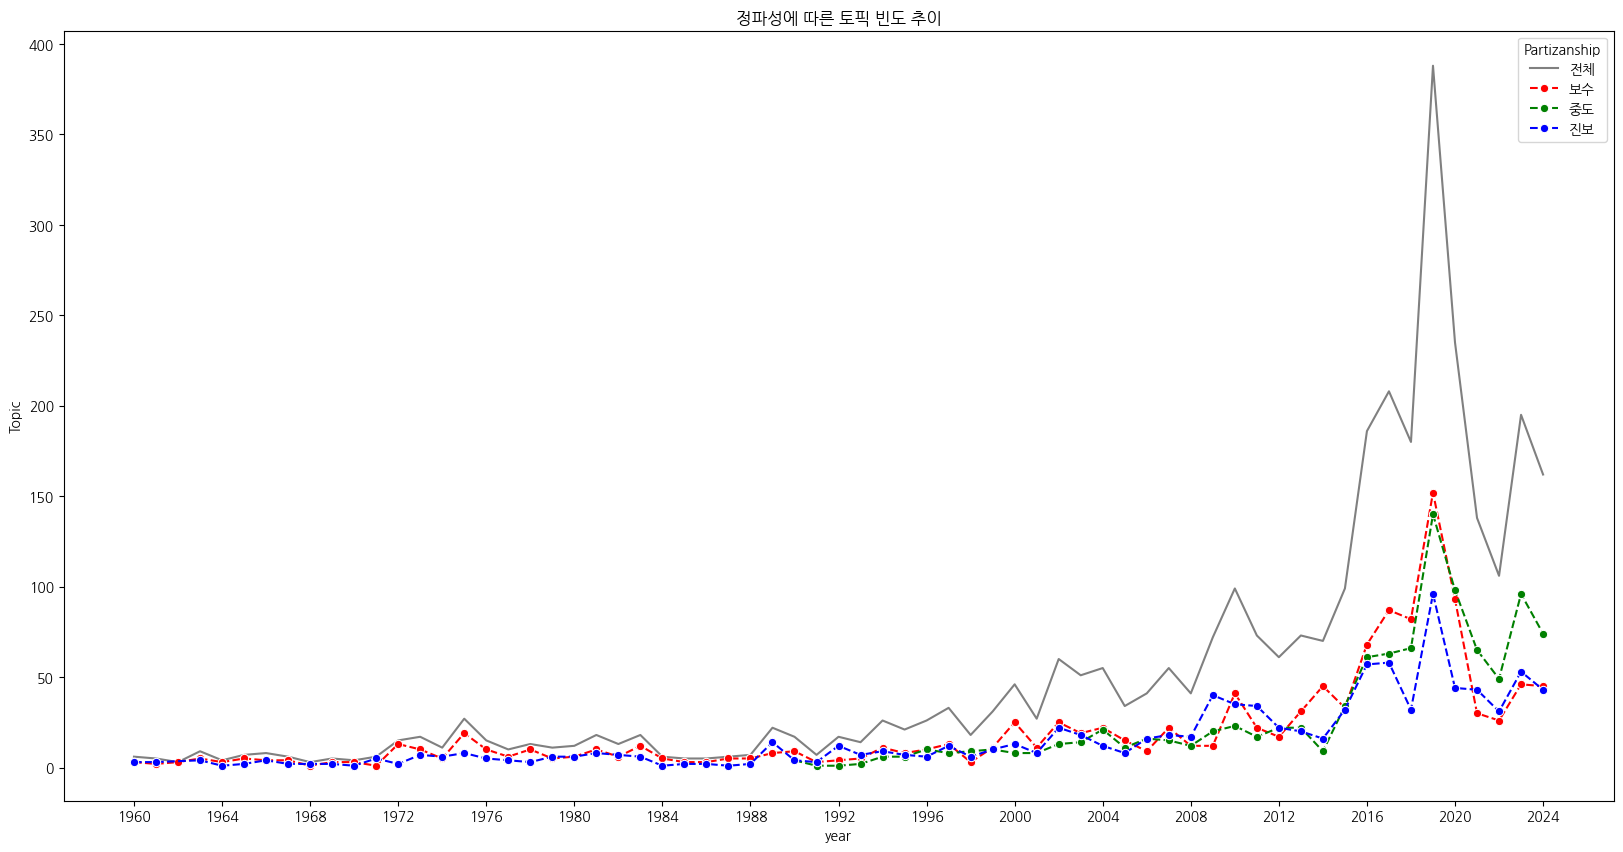

In [4]:
tmp1 = df.groupby("year").count()
tmp2 = df.groupby(["year", "Partizanship"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp1, x = "year", y = "Topic", label="전체", color="gray", linestyle='-')
sns.lineplot(data=tmp2, x = "year", y = "Topic", hue="Partizanship", palette=["red", "green", "blue"], linestyle='--',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("정파성에 따른 토픽 빈도 추이")
plt.show()

In [5]:
df[df["Group"].str.contains("사건")| df["Group"].str.contains("범죄")].groupby('Group').count()

,name,Year,Document,Topic,press,year,year_range,Partizanship
Group,,,,,,,,
강남역 살인 사건,105,105,105,105,105,105,105,105
안인득 진주 흉기난동 방화 사건,103,103,103,103,103,103,103,103
조현병 환자 범죄 관련 재판 결과,356,356,356,356,356,356,356,356
조현병과 강력범죄,201,201,201,201,201,201,201,201
조현병과 관련한 사건사고,214,214,214,214,214,214,214,214


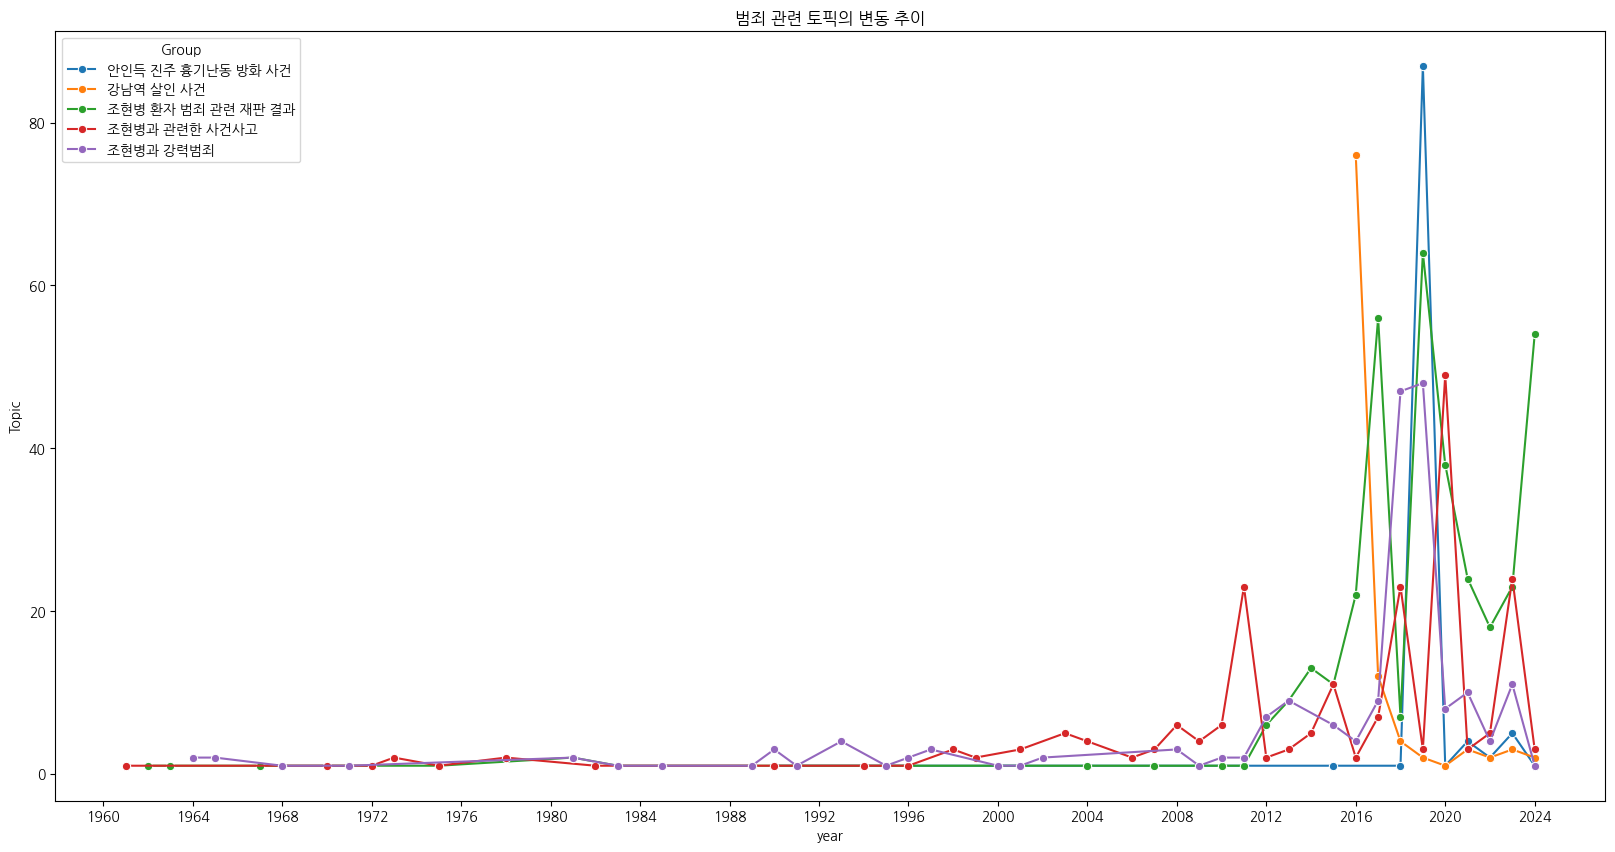

In [6]:
tmp = df[df["Group"].str.contains("사건")| df["Group"].str.contains("범죄")]\
    .groupby(["year", "Group"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data=tmp, x = "year", y = "Topic", hue = "Group", linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("범죄 관련 토픽의 변동 추이")
plt.show()

In [7]:
tmp1 = df[df["Partizanship"]=="진보"].groupby("Group").count().sort_values("name", ascending=False).reset_index()
tmp2 = df[df["Partizanship"]=="보수"].groupby("Group").count().sort_values("name", ascending=False).reset_index()
tmp3 = df[df["Partizanship"]=="중도"].groupby("Group").count().sort_values("name", ascending=False).reset_index()

tmp_merged = pd.concat([tmp1[["Group", "name"]], tmp2[["Group", "name"]], tmp3[["Group", "name"]]], axis=1)

tmp_merged.columns = ["진보 상위 토픽", "진보 토픽 빈도", "보수 상위 토픽", "보수 토픽 빈도", "중도 상위 토픽", "중도 토픽 빈도"]

tmp_merged.style.set_caption("정파성 별 조현병 토픽 기사 빈도")

,진보 상위 토픽,진보 토픽 빈도,보수 상위 토픽,보수 토픽 빈도,중도 상위 토픽,중도 토픽 빈도
0,조현병과 예술 작품,175,조현병과 예술 작품,284,조현병과 사회보건,223
1,조현병과 사회보건,162,조현병과 사회보건,155,조현병 환자 범죄 관련 재판 결과,153
2,조현병과 정치적 이슈,156,조현병과 사회적 이슈,143,조현병과 예술 작품,131
3,조현병과 사회적 이슈,106,조현병 관련 의학 연구,139,조현병 관련 의학 연구,113
4,조현병 관련 의학 연구,76,조현병 환자 범죄 관련 재판 결과,138,조현병과 사회적 이슈,91
5,조현병과 관련한 사건사고,71,조현병과 정치적 이슈,104,조현병과 정치적 이슈,85
6,조현병 환자 범죄 관련 재판 결과,65,조현병과 강력범죄,81,조현병과 강력범죄,70
7,강남역 살인 사건,51,조현병과 관련한 사건사고,73,조현병과 관련한 사건사고,70
8,조현병과 강력범죄,50,조현병과 신체검사,65,조현병과 신체검사,35
9,조현병과 신체검사,40,안인득 진주 흉기난동 방화 사건,40,안인득 진주 흉기난동 방화 사건,32


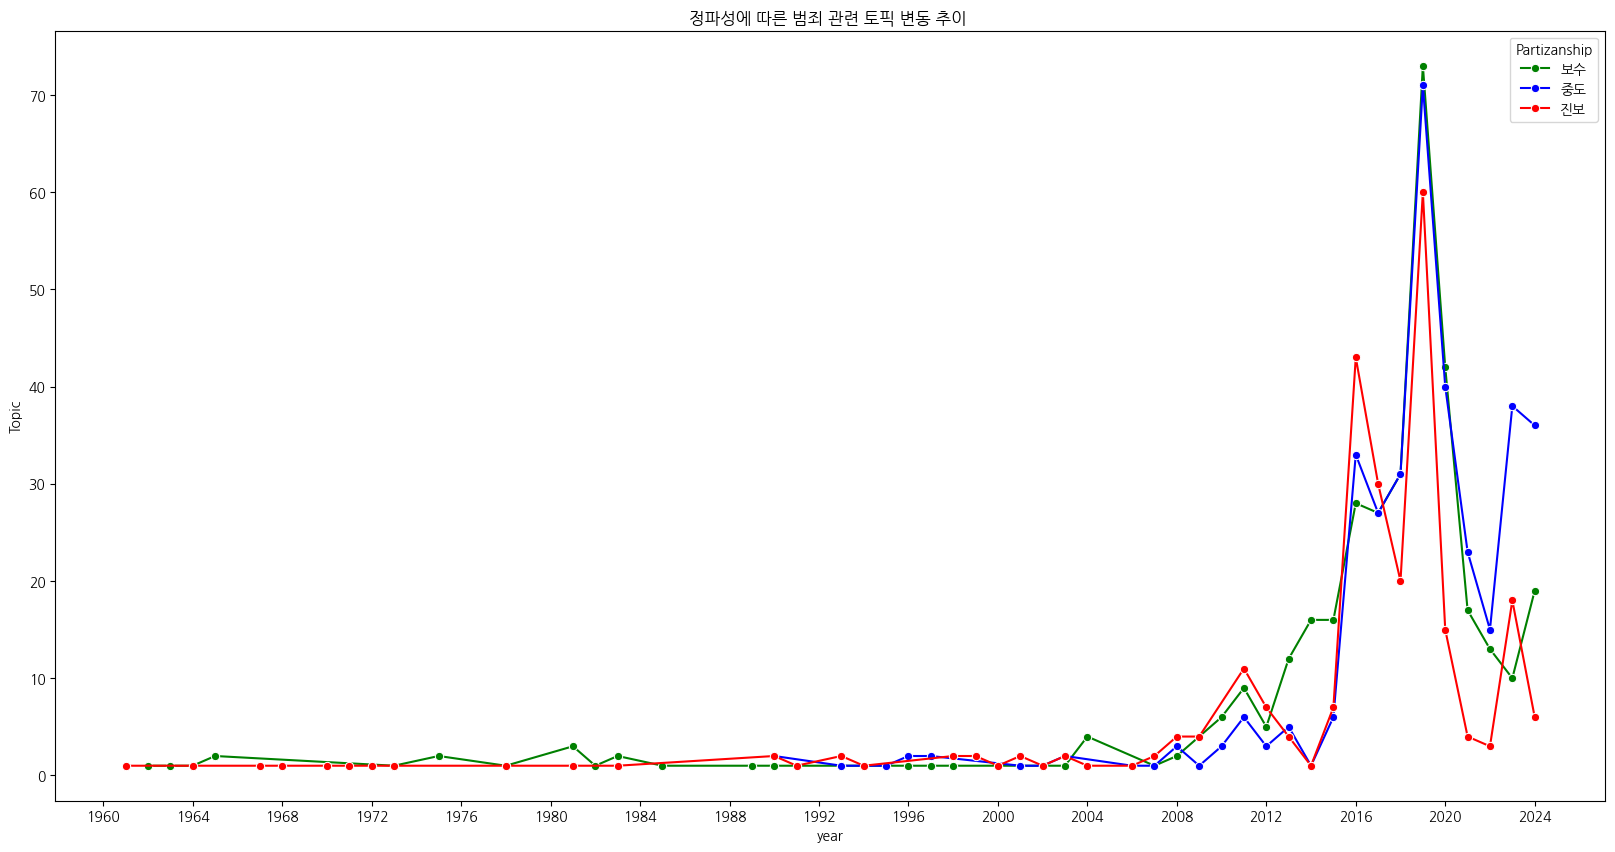

In [8]:
tmp = df[df["Group"].str.contains("사건")|
         df["Group"].str.contains("범죄")].groupby(["year", "Partizanship"]).count().sort_values("Topic", ascending=False).reset_index()

plt.figure(figsize=(20, 10))

sns.lineplot(data = tmp, x = "year", y = "Topic", hue="Partizanship", palette=["green", "blue", "red"], linestyle='-',marker='o')

plt.xticks([i for i in range(1960,2025,4)])

plt.title("정파성에 따른 범죄 관련 토픽 변동 추이 ")

plt.show()

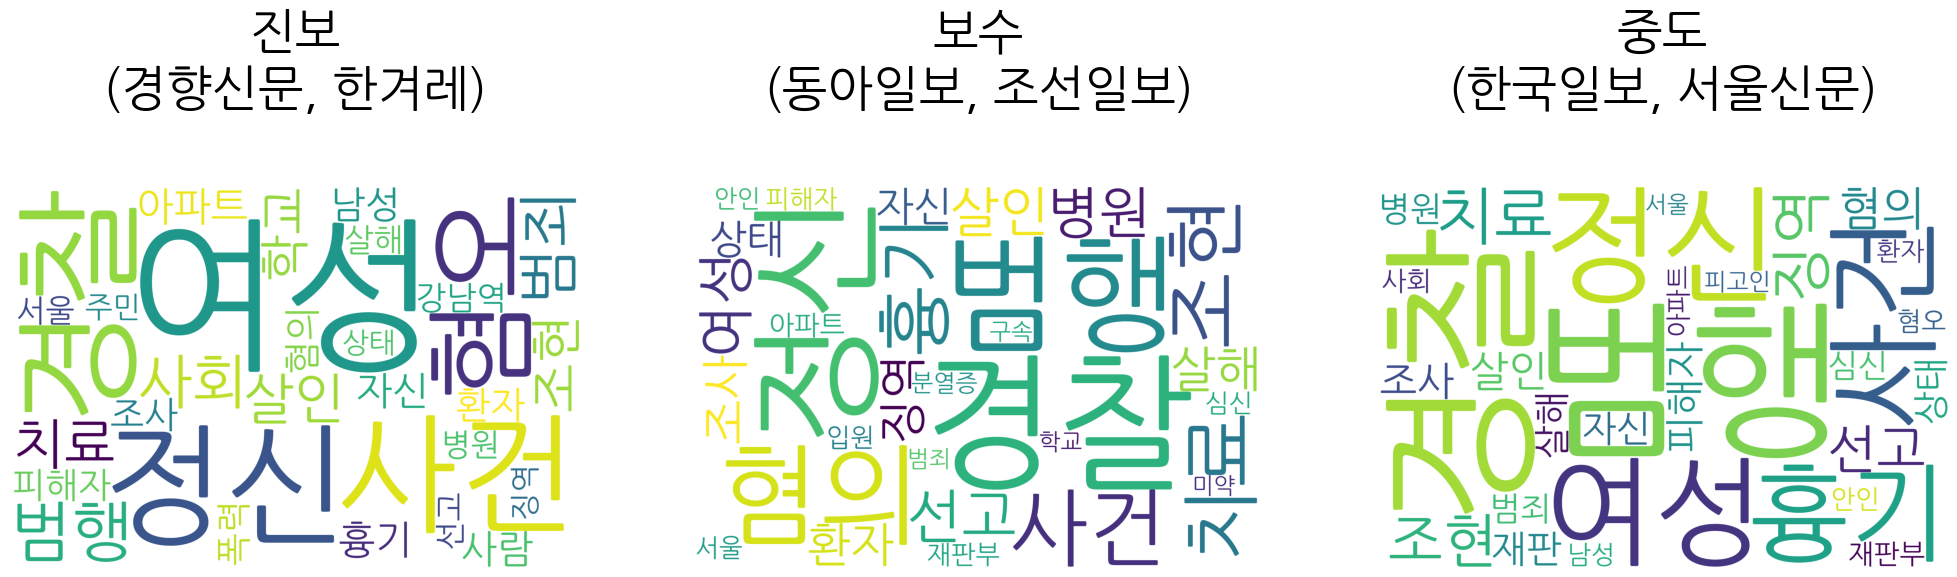

In [ ]:
category = df[df["Group"].str.contains("사건")|df["Group"].str.contains("범죄")]
category["키워드"] = category["Document"]

liberal = keyword_dataframe(category[category["Partizanship"] == "진보"])
conservative = keyword_dataframe(category[category["Partizanship"] == "보수"])
neutral = keyword_dataframe(category[category["Partizanship"] == "중도"])

wc = WordCloud(width = 3000, height = 2000, random_state=100,
              background_color="white", font_path="NanumGothic")

fig, ax = plt.subplots(1, 3, figsize=(25, 15))

dataframe = [liberal, conservative, neutral]
partizanship = ["진보", "보수", "중도"]
media_list = [", ".join(category[category["Partizanship"] == p]["press"].unique()) for p in ["진보", "보수", "중도"]]

for i in range(len(dataframe)):
    keywords = dataframe[i][:30].set_index("단어").to_dict()["빈도"]
    ax[i].imshow(wc.generate_from_frequencies(keywords))
    ax[i].set_title(f"{partizanship[i]}\n({media_list[i]})", fontsize=35, pad=60)
    ax[i].axis("off")
plt.show()